# Spotify Songs — Clustering

`spotify_songs.csv` — 32,833 rows x 23 columns, the same dataset as the EDA project.
Goal: group songs by how they sound, using the audio features only.

## Setup

In [1]:
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

pd.set_option("display.max_columns", 30)
pd.set_option("display.max_rows", 100)
pd.set_option("display.min_rows", 30)
sns.set_theme(style="whitegrid")

path = kagglehub.dataset_download("joebeachcapital/30000-spotify-songs")
df = pd.read_csv(f"{path}/spotify_songs.csv")

df.shape

/Users/rmsaah/PycharmProjects/TuwaiqClasses/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(32833, 23)

## Part 1 — Preprocessing

In [2]:
df = df.dropna(subset=["track_name", "track_artist", "track_album_name"])
df = df[df["duration_ms"] >= 10000]
df["duration_min"] = df["duration_ms"] / 60000

songs = df.drop_duplicates(subset="track_id").reset_index(drop=True)

print("playlist rows :", len(df))
print("unique songs  :", len(songs))
print("missing cells :", songs.isna().sum().sum())

playlist rows : 32827
unique songs  : 28351
missing cells : 0


### Feature selection

In [3]:
features = ["danceability", "energy", "speechiness", "acousticness",
            "instrumentalness", "liveness", "valence", "tempo", "duration_min"]

X = songs[features]
X.agg(["min", "max", "mean", "std"]).T.round(2)

,min,max,mean,std
danceability,0.08,0.98,0.65,0.15
energy,0.00,1.00,0.70,0.18
speechiness,0.02,0.92,0.11,0.10
acousticness,0.00,0.99,0.18,0.22
instrumentalness,0.00,0.99,0.09,0.23
liveness,0.01,1.00,0.19,0.16
valence,0.00,0.99,0.51,0.23
tempo,35.48,239.44,120.96,26.95
duration_min,0.49,8.63,3.78,1.02


### Scaling

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pd.DataFrame(X_scaled, columns=features).agg(["min", "max", "mean", "std"]).T.round(2)

,min,max,mean,std
danceability,-3.95,2.26,-0.0,1.0
energy,-3.81,1.64,-0.0,1.0
speechiness,-0.83,7.90,0.0,1.0
acousticness,-0.80,3.67,0.0,1.0
instrumentalness,-0.39,3.88,-0.0,1.0
liveness,-1.16,5.16,0.0,1.0
valence,-2.18,2.05,0.0,1.0
tempo,-3.17,4.40,-0.0,1.0
duration_min,-3.23,4.77,0.0,1.0


## Part 2 — Choosing k

In [5]:
k_range = range(2, 11)
inertia = []  #WCSS
silhouette = []

for k in k_range:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_scaled)
    inertia.append(model.inertia_)
    silhouette.append(silhouette_score(X_scaled, labels, sample_size=5000, random_state=42))

pd.DataFrame({
    "k": list(k_range),
    "inertia": np.round(inertia).astype(int),
    "silhouette": np.round(silhouette, 4),
})

,k,inertia,silhouette
0,2,224497,0.1334
1,3,199598,0.1414
2,4,180937,0.1501
3,5,165108,0.1507
4,6,153804,0.1547
5,7,146031,0.1415
6,8,139991,0.1393
7,9,134577,0.1461
8,10,129396,0.1387


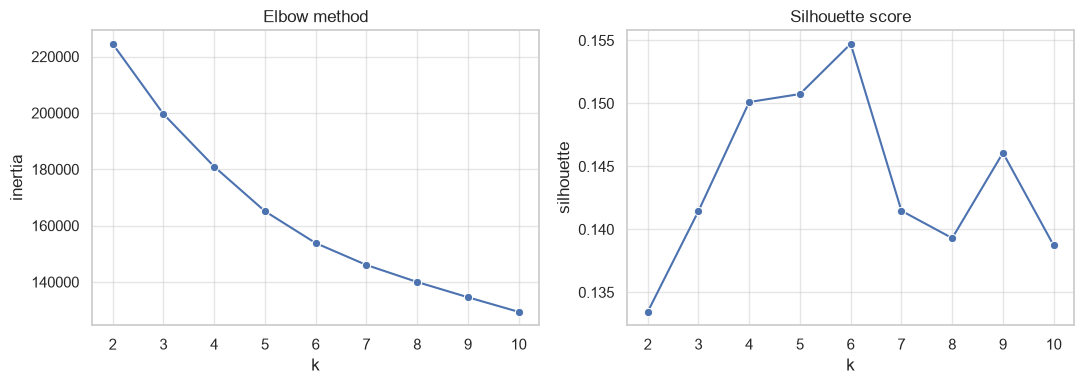

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.lineplot(x=list(k_range), y=inertia, marker="o", ax=axes[0])
axes[0].set_title("Elbow method")
axes[0].set_xlabel("k")
axes[0].set_ylabel("inertia")

sns.lineplot(x=list(k_range), y=silhouette, marker="o", ax=axes[1])
axes[1].set_title("Silhouette score")
axes[1].set_xlabel("k")
axes[1].set_ylabel("silhouette")

plt.tight_layout()
plt.show()

## Part 3 — Fitting the algorithms

In [7]:
k = 6

kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
songs["kmeans_cluster"] = kmeans.fit_predict(X_scaled)

gmm = GaussianMixture(n_components=k, random_state=42)
songs["gmm_cluster"] = gmm.fit_predict(X_scaled)

kmeans_score = silhouette_score(X_scaled, songs["kmeans_cluster"], sample_size=5000, random_state=42)
gmm_score = silhouette_score(X_scaled, songs["gmm_cluster"], sample_size=5000, random_state=42)

print("k-means silhouette:", round(kmeans_score, 4))
print("gmm silhouette    :", round(gmm_score, 4))

k-means silhouette: 0.1547
gmm silhouette    : -0.0133


## Part 4 — Visual inspection

In [8]:
pca = PCA(n_components=2, random_state=42)
components = pca.fit_transform(X_scaled)

songs["pc1"] = components[:, 0]
songs["pc2"] = components[:, 1]

print("variance kept:", pca.explained_variance_ratio_.round(3),
      "->", round(pca.explained_variance_ratio_.sum() * 100, 1), "%")

variance kept: [0.188 0.168] -> 35.6 %


In [9]:
pd.DataFrame(pca.components_.T, index=features, columns=["pc1", "pc2"]).round(2)

,pc1,pc2
danceability,-0.23,0.56
energy,0.63,0.22
speechiness,-0.11,0.34
acousticness,-0.59,-0.20
instrumentalness,0.06,-0.29
liveness,0.26,-0.03
valence,-0.01,0.59
tempo,0.30,-0.11
duration_min,0.15,-0.19


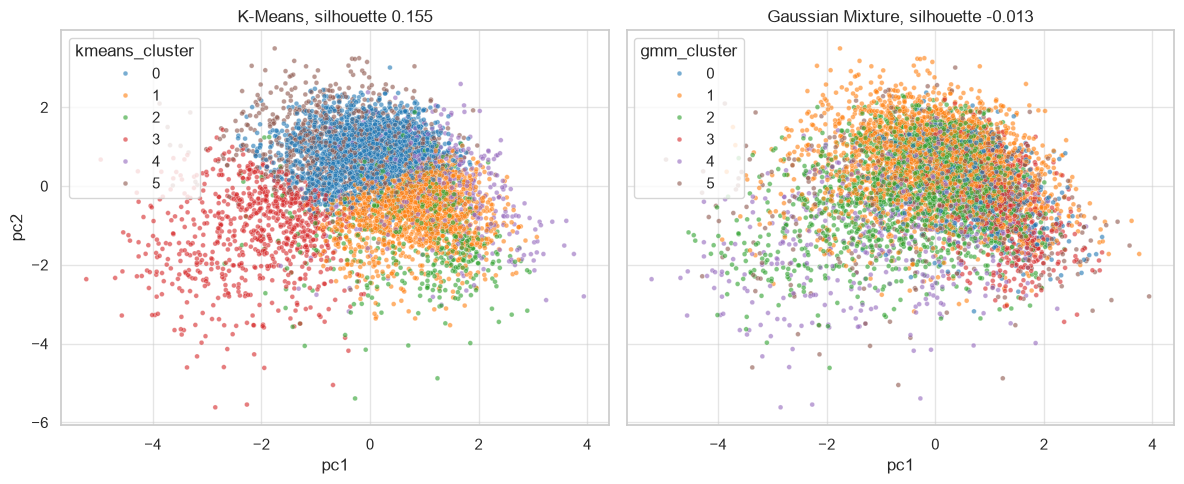

In [10]:
sample = songs.sample(6000, random_state=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

sns.scatterplot(data=sample, x="pc1", y="pc2", hue="kmeans_cluster",
                palette="tab10", s=12, alpha=0.6, ax=axes[0])
axes[0].set_title(f"K-Means, silhouette {kmeans_score:.3f}")

sns.scatterplot(data=sample, x="pc1", y="pc2", hue="gmm_cluster",
                palette="tab10", s=12, alpha=0.6, ax=axes[1])
axes[1].set_title(f"Gaussian Mixture, silhouette {gmm_score:.3f}")

plt.tight_layout()
plt.show()

## Part 5 — Cluster profiles

In [11]:
songs.groupby("kmeans_cluster")[features].mean().round(2)

,danceability,energy,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_min
kmeans_cluster,,,,,,,,,
0,0.74,0.72,0.07,0.14,0.02,0.15,0.68,113.80,3.73
1,0.54,0.77,0.07,0.07,0.02,0.17,0.37,132.72,3.84
2,0.66,0.77,0.07,0.08,0.75,0.17,0.39,124.97,4.20
3,0.60,0.43,0.07,0.59,0.10,0.15,0.39,111.69,3.66
4,0.61,0.78,0.11,0.12,0.06,0.61,0.51,122.40,3.87
5,0.73,0.66,0.31,0.19,0.01,0.18,0.54,121.39,3.59


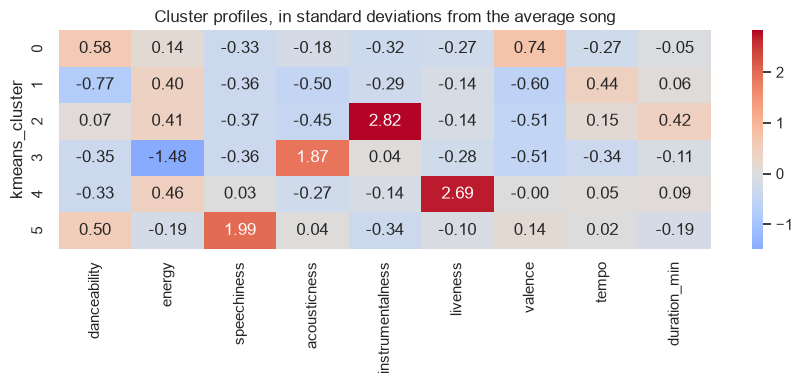

In [12]:
scaled_frame = pd.DataFrame(X_scaled, columns=features)
scaled_frame["kmeans_cluster"] = songs["kmeans_cluster"].values
cluster_profile = scaled_frame.groupby("kmeans_cluster").mean()

plt.figure(figsize=(9, 4))
sns.heatmap(cluster_profile, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Cluster profiles, in standard deviations from the average song")
plt.tight_layout()
plt.show()

### Size and popularity

In [13]:
pd.DataFrame({
    "songs": songs["kmeans_cluster"].value_counts().sort_index(),
    "percent": (songs["kmeans_cluster"].value_counts(normalize=True).sort_index() * 100).round(1),
    "mean_popularity": songs.groupby("kmeans_cluster")["track_popularity"].mean().round(2),
})

,songs,percent,mean_popularity
kmeans_cluster,,,
0,9270,32.7,41.17
1,7307,25.8,38.63
2,2330,8.2,29.68
3,3595,12.7,42.72
4,1951,6.9,36.08
5,3898,13.7,40.59


### Clusters against genre

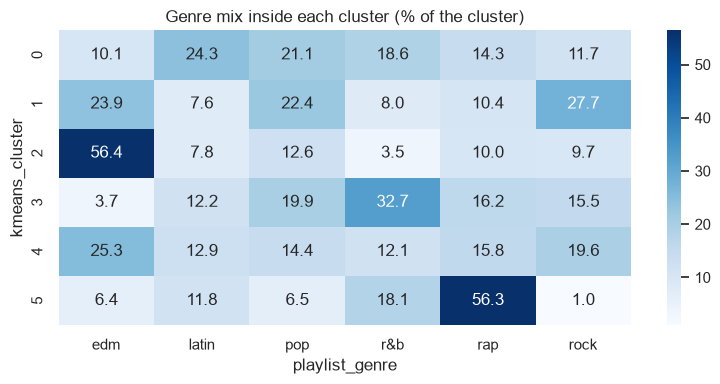

playlist_genre,edm,latin,pop,r&b,rap,rock
kmeans_cluster,,,,,,
0,10.1,24.3,21.1,18.6,14.3,11.7
1,23.9,7.6,22.4,8.0,10.4,27.7
2,56.4,7.8,12.6,3.5,10.0,9.7
3,3.7,12.2,19.9,32.7,16.2,15.5
4,25.3,12.9,14.4,12.1,15.8,19.6
5,6.4,11.8,6.5,18.1,56.3,1.0


In [14]:
genre_mix = pd.crosstab(songs["kmeans_cluster"], songs["playlist_genre"], normalize="index") * 100

plt.figure(figsize=(8, 4))
sns.heatmap(genre_mix.round(1), annot=True, fmt=".1f", cmap="Blues")
plt.title("Genre mix inside each cluster (% of the cluster)")
plt.tight_layout()
plt.show()

genre_mix.round(1)

### Naming the clusters

In [15]:
cluster_names = {
    0: "upbeat and danceable",
    1: "fast, hard, low mood",
    2: "instrumental",
    3: "acoustic and calm",
    4: "live recordings",
    5: "spoken word and rap",
}

songs["cluster_name"] = songs["kmeans_cluster"].map(cluster_names)

songs.sort_values("track_popularity", ascending=False) \
    .groupby("cluster_name").head(3) \
    [["cluster_name", "track_name", "track_artist", "playlist_genre", "track_popularity"]] \
    .sort_values(["cluster_name", "track_popularity"], ascending=[True, False])

,cluster_name,track_name,track_artist,playlist_genre,track_popularity
1504,acoustic and calm,Dance Monkey,Tones and I,pop,100
711,acoustic and calm,Memories,Maroon 5,pop,98
689,acoustic and calm,everything i wanted,Billie Eilish,pop,97
716,"fast, hard, low mood",Blinding Lights,The Weeknd,pop,98
730,"fast, hard, low mood",Heartless,The Weeknd,pop,93
1308,"fast, hard, low mood",How Do You Sleep?,Sam Smith,pop,91
16918,instrumental,Baila Conmigo (feat. Kelly Ruiz),Dayvi,latin,83
26149,instrumental,Losing It,FISHER,edm,79
20263,instrumental,In My Room,Frank Ocean,r&b,79
18026,live recordings,ROXANNE,Arizona Zervas,latin,99


## Part 6 — Comparison

In [16]:
pd.DataFrame({
    "algorithm": ["K-Means", "Gaussian Mixture"],
    "clusters": [songs["kmeans_cluster"].nunique(), songs["gmm_cluster"].nunique()],
    "silhouette": [round(kmeans_score, 4), round(gmm_score, 4)],
    "smallest": [songs["kmeans_cluster"].value_counts().min(), songs["gmm_cluster"].value_counts().min()],
    "largest": [songs["kmeans_cluster"].value_counts().max(), songs["gmm_cluster"].value_counts().max()],
})

,algorithm,clusters,silhouette,smallest,largest
0,K-Means,6,0.1547,1951,9270
1,Gaussian Mixture,6,-0.0133,2244,10431
